
# Credit Decisioning - Model Explainability and Fairness

<img src="https://raw.githubusercontent.com/databricks-demos/dbdemos-resources/main/images/fsi/credit_decisioning/fsi-credit-decisioning-ml-4.png" style="float: right" width="800px">


Machine learning (ML) models are increasingly being used in credit decisioning to automate lending processes, reduce costs, and improve accuracy. 

As ML models become more complex and data-driven, their decision-making processes can become opaque, making it challenging to understand how decisions are made, and to ensure that they are fair and non-discriminatory. 

Therefore, it is essential to develop techniques that enable model explainability and fairness in credit decisioning to ensure that the use of ML does not perpetuate existing biases or discrimination. 

In this context, explainability refers to the ability to understand how an ML model is making its decisions, while fairness refers to ensuring that the model is not discriminating against certain groups of people. 

## Ensuring model fairness for new credit customers

In this example, we'll make sure that our model behaves as expected and is fair for our new customers.

We'll select our existing customers not having credit (We'll flag them as `defaulted = 2`) and make sure that our model is fair and behave the same among different group of the population.

<!-- Collect usage data (view). Remove it to disable collection. View README for more details.  -->
<img width="1px" src="https://ppxrzfxige.execute-api.us-west-2.amazonaws.com/v1/analytics?category=lakehouse&org_id=2162748966026566&notebook=%2F03-Data-Science-ML%2F03.5-Explainability-and-Fairness-credit-decisioning&demo_name=lakehouse-fsi-credit&event=VIEW&path=%2F_dbdemos%2Flakehouse%2Flakehouse-fsi-credit%2F03-Data-Science-ML%2F03.5-Explainability-and-Fairness-credit-decisioning&version=1">

In [0]:
%pip install --quiet shap==0.46.0 mlflow==2.22.0
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%run ../_resources/00-setup $reset_all_data=false

USE CATALOG `main__build`
using catalog.database `main__build`.`dbdemos_fsi_credit_decisioning`


In [0]:
import mlflow
from mlflow.store.artifact.models_artifact_repo import ModelsArtifactRepository

# Configure MLflow to use Unity Catalog instead of Workspace Model Registry
mlflow.set_registry_uri('databricks-uc')

requirements_path = ModelsArtifactRepository(f"models:/{catalog}.{db}.dbdemos_fsi_credit_decisioning@prod").download_artifacts(artifact_path="requirements.txt")

In [0]:
%pip install --quiet -r $requirements_path
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%run ../_resources/00-setup $reset_all_data=false

USE CATALOG `main__build`
using catalog.database `main__build`.`dbdemos_fsi_credit_decisioning`



Here we are merging several PII columns (hence we read from the ```customer_silver``` table) with the model prediction output table for visualizing them on the dashboard for end user consumption

In [0]:
feature_df = spark.table("credit_decisioning_features")
credit_bureau_label = spark.table("credit_bureau_gold")
customer_df = spark.table(f"customer_silver").select("cust_id", "gender", "first_name", "last_name", "email", "mobile_phone")
                   
df = (feature_df.join(customer_df, "cust_id", how="left")
               .join(credit_bureau_label, "cust_id", how="left")
               .withColumn("defaulted", F.when(col("CREDIT_DAY_OVERDUE").isNull(), 2)
                                         .when(col("CREDIT_DAY_OVERDUE") > 60, 1)
                                         .otherwise(0))
               .drop('CREDIT_DAY_OVERDUE')
               .fillna(0))
display(df)

cust_id,education,marital_status,months_current_address,months_employment,is_resident,tenure_months,product_cnt,tot_rel_bal,revenue_tot,revenue_12m,income_annual,tot_assets,overdraft_balance_amount,overdraft_number,total_deposits_number,total_deposits_amount,total_equity_amount,total_UT,customer_revenue,age,avg_balance,num_accs,balance_usd,available_balance_usd,is_pre_paid,number_payment_delays_last12mo,pct_increase_annual_number_of_delays_last_3_year,phone_bill_amt,avg_phone_bill_amt_lst12mo,dist_payer_cnt_12m,sent_txn_cnt_12m,sent_txn_amt_12m,sent_amt_avg_12m,dist_payee_cnt_12m,rcvd_txn_cnt_12m,rcvd_txn_amt_12m,rcvd_amt_avg_12m,dist_payer_cnt_6m,sent_txn_cnt_6m,sent_txn_amt_6m,sent_amt_avg_6m,dist_payee_cnt_6m,rcvd_txn_cnt_6m,rcvd_txn_amt_6m,rcvd_amt_avg_6m,dist_payer_cnt_3m,sent_txn_cnt_3m,sent_txn_amt_3m,sent_amt_avg_3m,dist_payee_cnt_3m,rcvd_txn_cnt_3m,rcvd_txn_amt_3m,rcvd_amt_avg_3m,tot_txn_cnt_12m,tot_txn_amt_12m,tot_txn_cnt_6m,tot_txn_amt_6m,tot_txn_cnt_3m,tot_txn_amt_3m,ratio_txn_amt_3m_12m,ratio_txn_amt_6m_12m,gender,first_name,last_name,email,mobile_phone,AMT_CREDIT_MAX_OVERDUE,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CNT_CREDIT_PROLONG,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,SK_BUREAU_ID,SK_ID_CURR,_rescued_data,defaulted
50,2,1,44,84,0,97,1,1724.38,488.28,0.42,102732,1027,9.174683159E7,0,1,4444568.95,4694267.39,7073893.86,7136809.0,30,221.0,1,221.0,1527.37,1,0,0,41.98,41.98,0,0,0.0,0.0,1,3,652.39,217.46333333333334,0,0,0.0,0.0,1,1,273.64,273.64,0,0,0.0,0.0,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,Female,Elbertine,Boyson,eboyson1d@angelfire.com,656-974-2232,0,82,6008,2058,0,0,0,USD,88,101,85,8610,8610,null,0
518,3,0,63,1,1,149,2,19001.77,998.81,0.56,79932,79932,5.7386063884E8,7,8,6040180.0,1406166.33,4776694.0,2510863.0,26,2853.49,1,2853.49,2158.52,0,0,0,49.99,49.99,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,Male,Trace,Cannell,tcannelled@discovery.com,350-961-1308,0,733,990,640,0,0,0,USD,93,143,0,8829,8829,null,0
750,2,2,39,13,1,106,1,887.05,1185.08,0.93,113064,1130,6.6827429023E8,0,2,3650389.75,1358955.35,5125404.0,4351280.78,48,6195.85,1,6195.85,383.93,0,0,0,89.99,89.99,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,Male,Darrell,Mingaud,dmingaudkt@biglobe.ne.jp,322-449-0468,0,0,0,0,0,0,0,null,0,0,0,0,0,null,2
771,0,1,14,1,0,25,4,36.0,602.69,2.01,35124,0,5.4086133119E8,6,10,9841140.0,8151069.17,6874894.31,2929922.0,61,4113.1,1,4113.1,239.02,0,0,0,19.99,19.99,0,0,0.0,0.0,1,13,2727.92,209.84,0,0,0.0,0.0,1,6,1367.2800000000002,227.88000000000002,0,0,0.0,0.0,1,4,941.4200000000001,235.35500000000002,0,0.0,0,0.0,0,0.0,0.0,0.0,Female,Vic,Mammatt,vmammattle@discovery.com,847-443-9372,0,0,0,0,0,0,0,null,0,0,0,0,0,null,2
951,4,0,3,96,0,53,1,5871.96,932.9,1.47,90396,903,6.0880169558E8,4,7,1831504.53,5062367.0,8619780.0,6764816.0,34,1457.285,2,2623.82,1163.27,0,0,0,49.99,49.99,0,0,0.0,0.0,1,30,6022.539999999999,200.7513333333333,0,0,0.0,0.0,1,17,3462.6299999999997,203.6841176470588,0,0,0.0,0.0,1,9,2013.5700000000002,223.73000000000002,0,0.0,0,0.0,0,0.0,0.0,0.0,Male,Zebadiah,Learmond,zlearmondqe@china.com.cn,444-494-7536,0,840,784,1684,0,0,1,USD,106,98,0,9033,9033,null,0
1214,0,0,1,56,1,112,2,18646.11,1268.21,0.94,55752,557,7.358438545E8,9,10,9097153.0,3723241.0,1394711.4,7189156.0,30,3864.9,1,3864.9,1282.52,0,0,0,19.99,19.99,0,0,0.0,0.0,1,7,1508.99,215.57,0,0,0.0,0.0,1,2,511.71000000000004,255.85500000000002,0,0,0.0,0.0,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,Male,Sam,Waeland,swaelandxp@auda.org.au,310-867-6274,0,529,1588,622,0,0,1,USD,70,162,0,9152,9152,null,0
1414,4,2,56,73,0,1,4,8151.14,898.48,74.87,42720,0,5.6594330063E8,6,4,6437599.0,5272965.0,4135071.33,9910672.0,26,224.33333333333334,3,673.0,0.0,1,3,1,131.98,131.98,1,1,113.37,113.37,1,1,232.71,232.71,1,1,113.37,113.37,1,1,232.71,232.71,0,0,0.0,0.0,1,1,232.71,232.71,2,346.08000000000004,2,346.0

## Load Model from the registry

In [0]:
model_name = "dbdemos_fsi_credit_decisioning"
import mlflow
mlflow.set_registry_uri('databricks-uc')

model = mlflow.pyfunc.load_model(model_uri=f"models:/{catalog}.{db}.{model_name}@prod")
features = model.metadata.get_input_schema().input_names()

In [0]:
underbanked_df = df[df.defaulted==2].toPandas() # Features for underbanked customers
banked_df = df[df.defaulted!=2].toPandas() # Features for rest of the customers

## Feature importance using Shapley values

SHAP is a game-theoretic approach to explain machine learning models, providing a summary plot
of the relationship between features and model output. Features are ranked in descending order of
importance, and impact/color describe the correlation between the feature and the target variable.
- Generating SHAP feature importance is a very memory intensive operation.<br />
- To reduce the computational overhead of each trial, a single example is sampled from the underbanked set to explain.<br />
  For more thorough results, increase the sample size of explanations, or provide your own examples to explain.
- SHAP cannot explain models using data with nulls; if your dataset has any, both the background data and
  examples to explain will be imputed using the mode (most frequent values). This affects the computed
  SHAP values, as the imputed samples may not match the actual data distribution.

For more information on how to read Shapley values, see the [SHAP documentation](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html).

In [0]:
mlflow.autolog(disable=True)
mlflow.sklearn.autolog(disable=True)

import shap
train_sample = banked_df[features].sample(n=np.minimum(100, banked_df.shape[0]), random_state=42)
underbanked_sample = underbanked_df.sample(n=np.minimum(100, underbanked_df.shape[0]), random_state=42)

# Use Kernel SHAP to explain feature importance on the sampled rows from the validation set.
predict = lambda x: model.predict(pd.DataFrame(x, columns=features).astype(train_sample.dtypes.to_dict()))

explainer = shap.KernelExplainer(predict, train_sample, link="identity")
shap_values = explainer.shap_values(underbanked_sample[features], l1_reg=False, nsamples=100)

  0%|          | 0/100 [00:00<?, ?it/s]

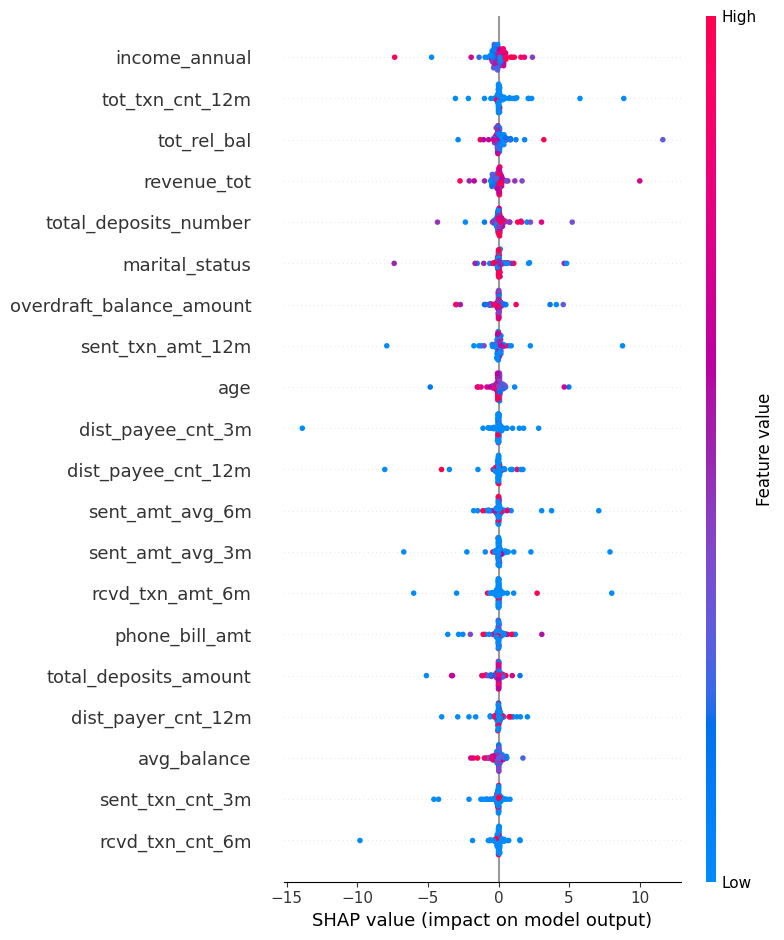

In [0]:
shap.summary_plot(shap_values, underbanked_sample[features])

Shapely values can also help for the analysis of local, instance-wise effects. 

We can also easily explain which feature impacted the decision for a given user. This can helps agent to understand the model an apply additional checks or control if required.

In [0]:
#shap.initjs()
#We'll need to add shap bundle js to display nice graph
with open(shap.__file__[:shap.__file__.rfind('/')]+"/plots/resources/bundle.js", 'r') as file:
   shap_bundle_js = '<script type="text/javascript">'+file.read()+';</script>'

html = shap.force_plot(explainer.expected_value, shap_values[0,:], underbanked_sample[features].iloc[0,:])
displayHTML(shap_bundle_js + html.html())

## Model fairness using Shapley values

In order to detect discriminatory outcomes in Machine Learning predictions, it is important to evaluate how the model treats various customer groups. This can be achieved by devising a metric, such as such as demographic parity, equal opportunity or equal odds, that defines fairness within the model. For example, when considering credit decisioning, we can compare the credit approval rates of male and female customers. In the notebook, we utilize Demographic Parity as a statistical measure of fairness, which asserts that there should be no difference between groups obtaining positive outcomes (e.g., credit approvals) in an ideal scenario. However, such perfect equality is rare, underscoring the need to monitor and address any gaps or discrepancies.

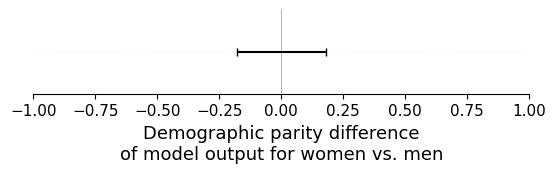

In [0]:
gender_array = underbanked_df['gender'].replace({'Female':0, 'Male':1}).to_numpy()
shap.group_difference_plot(shap_values.sum(1), \
                           gender_array, \
                           xmin=-1.0, xmax=1.0, \
                           xlabel="Demographic parity difference\nof model output for women vs. men")

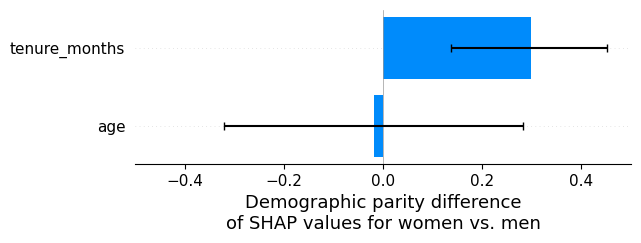

In [0]:
shap_df = pd.DataFrame(shap_values, columns=features).add_suffix('_shap')

shap.group_difference_plot(shap_df[['age_shap', 'tenure_months_shap']].to_numpy(), \
                           gender_array, \
                           feature_names=['age', 'tenure_months'], 
                           xmin=-0.5, xmax=0.5, \
                           xlabel="Demographic parity difference\nof SHAP values for women vs. men")


## Store Data (into Delta format) for Downstream Usage

Since we want to add the Explainability and Fairness assessment in the business dashboards, we will persist this data into Delta format and query it later.

In [0]:
#Let's load the underlying model to get the proba
skmodel = mlflow.sklearn.load_model(model_uri=f"models:/{catalog}.{db}.{model_name}@prod")
underbanked_sample['default_prob'] = skmodel.predict_proba(underbanked_sample[features])[:,1]
underbanked_sample['prediction'] = skmodel.predict(underbanked_sample[features])
final_df = pd.concat([underbanked_sample.reset_index(), shap_df], axis=1)

final_df = spark.createDataFrame(final_df).withColumn("default_prob", col("default_prob").cast('double'))
display(final_df)
final_df.drop('CREDIT_CURRENCY', '_rescued_data') \
        .write.mode("overwrite").option('mergeSchema', True).saveAsTable(f"shap_explanation")

index,cust_id,education,marital_status,months_current_address,months_employment,is_resident,tenure_months,product_cnt,tot_rel_bal,revenue_tot,revenue_12m,income_annual,tot_assets,overdraft_balance_amount,overdraft_number,total_deposits_number,total_deposits_amount,total_equity_amount,total_UT,customer_revenue,age,avg_balance,num_accs,balance_usd,available_balance_usd,is_pre_paid,number_payment_delays_last12mo,pct_increase_annual_number_of_delays_last_3_year,phone_bill_amt,avg_phone_bill_amt_lst12mo,dist_payer_cnt_12m,sent_txn_cnt_12m,sent_txn_amt_12m,sent_amt_avg_12m,dist_payee_cnt_12m,rcvd_txn_cnt_12m,rcvd_txn_amt_12m,rcvd_amt_avg_12m,dist_payer_cnt_6m,sent_txn_cnt_6m,sent_txn_amt_6m,sent_amt_avg_6m,dist_payee_cnt_6m,rcvd_txn_cnt_6m,rcvd_txn_amt_6m,rcvd_amt_avg_6m,dist_payer_cnt_3m,sent_txn_cnt_3m,sent_txn_amt_3m,sent_amt_avg_3m,dist_payee_cnt_3m,rcvd_txn_cnt_3m,rcvd_txn_amt_3m,rcvd_amt_avg_3m,tot_txn_cnt_12m,tot_txn_amt_12m,tot_txn_cnt_6m,tot_txn_amt_6m,tot_txn_cnt_3m,tot_txn_amt_3m,ratio_txn_amt_3m_12m,ratio_txn_amt_6m_12m,gender,first_name,last_name,email,mobile_phone,AMT_CREDIT_MAX_OVERDUE,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CNT_CREDIT_PROLONG,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,SK_BUREAU_ID,SK_ID_CURR,_rescued_data,defaulted,default_prob,prediction,education_shap,marital_status_shap,months_current_address_shap,months_employment_shap,is_resident_shap,tenure_months_shap,product_cnt_shap,tot_rel_bal_shap,revenue_tot_shap,revenue_12m_shap,income_annual_shap,tot_assets_shap,overdraft_balance_amount_shap,overdraft_number_shap,total_deposits_number_shap,total_deposits_amount_shap,total_equity_amount_shap,total_UT_shap,customer_revenue_shap,age_shap,avg_balance_shap,num_accs_shap,balance_usd_shap,available_balance_usd_shap,is_pre_paid_shap,number_payment_delays_last12mo_shap,pct_increase_annual_number_of_delays_last_3_year_shap,phone_bill_amt_shap,avg_phone_bill_amt_lst12mo_shap,dist_payer_cnt_12m_shap,sent_txn_cnt_12m_shap,sent_txn_amt_12m_shap,sent_amt_avg_12m_shap,dist_payee_cnt_12m_shap,rcvd_txn_cnt_12m_shap,rcvd_txn_amt_12m_shap,rcvd_amt_avg_12m_shap,dist_payer_cnt_6m_shap,sent_txn_cnt_6m_shap,sent_txn_amt_6m_shap,sent_amt_avg_6m_shap,dist_payee_cnt_6m_shap,rcvd_txn_cnt_6m_shap,rcvd_txn_amt_6m_shap,rcvd_amt_avg_6m_shap,dist_payer_cnt_3m_shap,sent_txn_cnt_3m_shap,sent_txn_amt_3m_shap,sent_amt_avg_3m_shap,dist_payee_cnt_3m_shap,rcvd_txn_cnt_3m_shap,rcvd_txn_amt_3m_shap,rcvd_amt_avg_3m_shap,tot_txn_cnt_12m_shap,tot_txn_amt_12m_shap,tot_txn_cnt_6m_shap,tot_txn_amt_6m_shap,tot_txn_cnt_3m_shap,tot_txn_amt_3m_shap,ratio_txn_amt_3m_12m_shap,ratio_txn_amt_6m_12m_shap
41158,54335,1,0,35,1,1,154,4,11445.39,877.29,0.47,45564,0,8.5507913673E8,8,1,5494950.0,1107468.0,542993.05,1375061.74,31,8685.9,1,8685.9,776.95,0,0,4,49.99,49.99,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,Female,Mei,Sange,msange15xa@simplemachines.org,475-121-0169,0,0,0,0,0,0,0,null,0,0,0,0,0,null,2,0.011250362731516361,0,-0.8928139385511656,-0.628266210057694,0.316436320016623,2.434187775894719,1.5562160086760874,0.0,0.0,0.847813938551149,-0.5075728938196057,0.006318152529829198,-1.3814759986920486,-0.11365355417624189,1.2428227516788577,-1.3992304712383585,-0.06000000000002387,-0.15371255018004298,0.0,0.38730756748000883,0.4859354184459356,0.06500000000008446,0.3189311930293886,-1.0759724660774155,-0.39535869991827804,0.647041273048021,1.342729778436426,-0.8870962475299465,-2.0837511977257384,0.628266210057718,0.9745409809546819,0.2597728610708518,0.0,0.8956687406410951,0.0,0.0335724931110965,0.0,-1.1944218147530397,-2.016011393935774,0.0,0.0,-1.3929123187086134,0.2288805275115922,0.0,0.6282662100577161,0.0,-0.8703391600302948,-0.005582640529398264,-0.9159952574556736,-0.03357249311112406,1.0764759986920298,0.0,-0.8063456296690542,1.075972466077439,0.0,0.0,0.8119282701984551,0.0,0.0,0.0,0.0,0.0,0.0
14750,32193,4,2,28,8,1,116,2,1


## Conclusion: the power of the Lakehouse

In this demo, we've seen an end 2 end flow with the Lakehouse:

- Data ingestion made simple with Spark Declarative Pipelines
- Leveraging Databricks warehouse to making credit decisions
- Model Training with AutoML for citizen Data Scientist
- Ability to tune our model for better results, improving our revenue
- Ultimately, the ability to deploy and make explainable ML predictions, made possible with the full Lakehouse capabilities.

[Go back to the introduction]($../00-Credit-Decisioning) or discover how to use Databricks Workflow to orchestrate this tasks: [06-Workflow-Orchestration-credit-decisioning]($../06-Workflow-Orchestration/06-Workflow-Orchestration-credit-decisioning)